# Explore Data Demand Forecasting

Explore data focus on explore the data through queries, visualizations, and reports to answer business questions and identify patterns relevant to the machine learning goals.

## Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from omegaconf import OmegaConf
from olist_ml.config import OlistConfig
from sqlalchemy import create_engine
from sklearn.preprocessing import MinMaxScaler

root_path = project_root=Path.cwd().parent.parent
cfg = OmegaConf.load("../../conf/config.yaml")

raw_data_path = root_path / cfg.paths.raw_data
olist_sqlite_path = raw_data_path / cfg.files.olist_sqlite
db_file = f"sqlite:///{olist_sqlite_path}"
engine = create_engine(db_file)
orders = pd.read_sql("SELECT * FROM orders;", engine)
order_items = pd.read_sql("SELECT * FROM order_items;", engine)
products = pd.read_sql("SELECT * FROM products;", engine)
customers = pd.read_sql("SELECT * FROM customers;", engine)
product_category_name_translation = pd.read_sql("SELECT * FROM product_category_name_translation;", engine)
order_payments = pd.read_sql("SELECT * FROM order_payments;", engine)
order_reviews = pd.read_sql("SELECT * FROM order_reviews;", engine)
sellers = pd.read_sql("SELECT * FROM sellers;", engine)
geolocation = pd.read_sql("SELECT * FROM geolocation;", engine)
leads_closed = pd.read_sql("SELECT * FROM leads_closed;", engine)
leads_qualified = pd.read_sql("SELECT * FROM leads_qualified;", engine)

## Business Questions

1. Do any products have sufficient order item volume (≥ 3,000)?
2. Do any product categories have sufficient order item volume (≥ 3,000)?
3. How does demand behave over time at the product category level (stability and seasonality)?
4. How do price and freight cost variations relate to demand?
5. How strong is the positive correlation between total cost and order item demand?

### 1. Do any products have sufficient order item volume (≥ 3,000)?

In [2]:
order_items_merged = pd.merge(
    order_items,
    orders,
    how="left",
    on="order_id"
)

date_cols = [
    'shipping_limit_date',
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    order_items_merged[col] = pd.to_datetime(order_items_merged[col])

products_to_keep = (
    order_items_merged
    .groupby("product_id")
    .size()
    .loc[lambda x: x >= 3000]
    .index
)
order_items_filtered = order_items_merged[
    order_items_merged["product_id"].isin(products_to_keep)
]
print(
    f"Total order items products: "
    f"{len(order_items_merged['product_id'].unique())} (order items merged products), "
    f"{len(order_items_filtered['product_id'].unique())} (order items filtered products)"
)

Total order items products: 32951 (order items merged products), 0 (order items filtered products)


**Answer:** No. At the product demand level, no product has a sufficient number of order items. A lower number of order items limits the ability to identify reliable demand patterns.

### 2. Do any product categories have sufficient order item volume (≥ 3,000)?

In [3]:
order_items_merged = pd.merge(
    pd.merge(
        order_items,
        pd.merge(
            products,
            product_category_name_translation,
            how="left",
            on="product_category_name"
        ),
        how="left",
        on="product_id"
    ),
    orders,
    how="left",
    on="order_id"
)

date_cols = [
    'shipping_limit_date',
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    order_items_merged[col] = pd.to_datetime(order_items_merged[col])

categories_to_keep = (
    order_items_merged
    .groupby("product_category_name")
    .size()
    .loc[lambda x: x >= 3000]
    .index
)
order_items_filtered = order_items_merged[
    order_items_merged["product_category_name"].isin(categories_to_keep)
]
print(
    f"Total order items product categories: "
    f"{len(order_items_merged['product_category_name'].unique())} (order items merged product categories), "
    f"{len(order_items_filtered['product_category_name'].unique())} (order items filtered product categories)"
)

Total order items product categories: 74 (order items merged product categories), 14 (order items filtered product categories)


**Answer:** At the product category level, 14 product categories have sufficient order item volume.

### 3. How does demand behave over time at the product category level (stability and seasonality)?

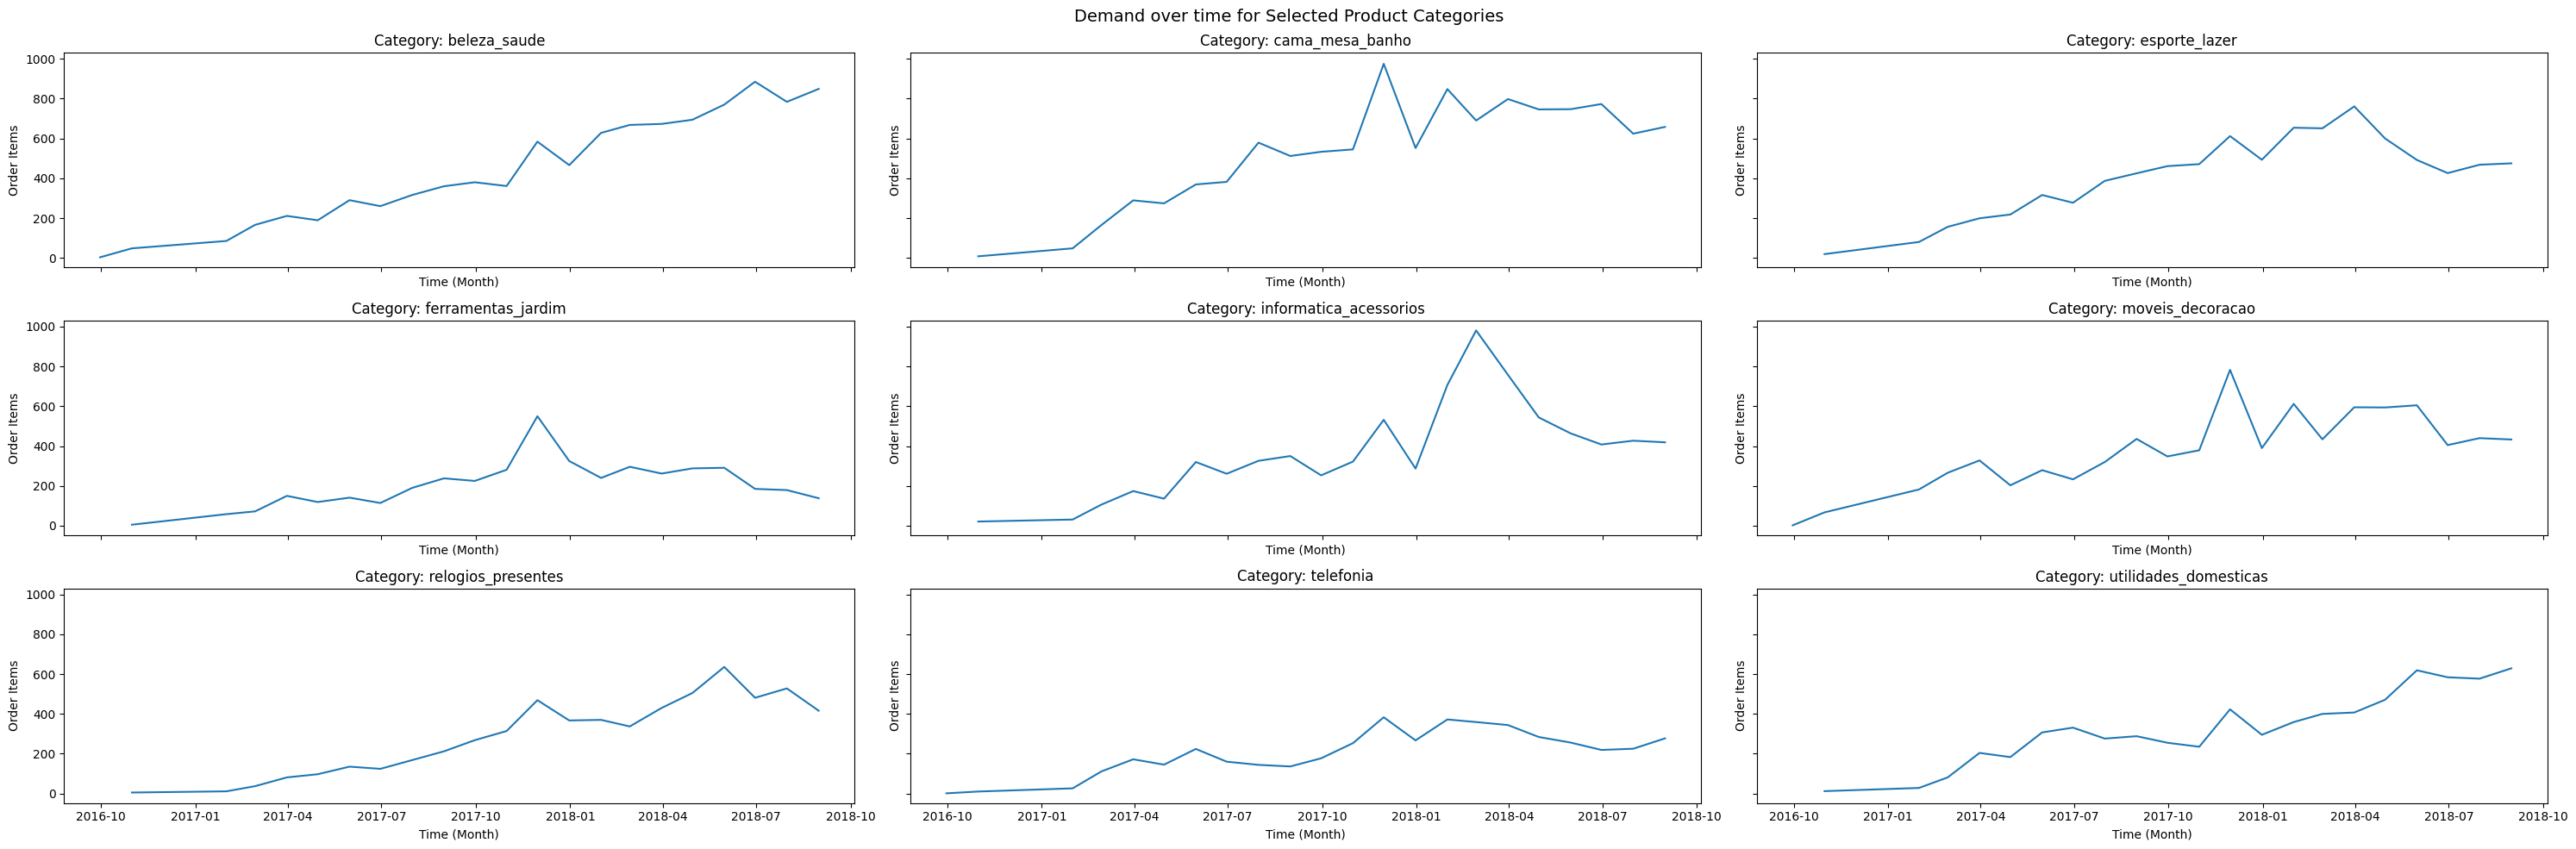

In [4]:
order_items_by_category = order_items_filtered.groupby("product_category_name").size().sort_values(ascending=False)
n_categories = len(order_items_by_category)
sampled_categories = order_items_by_category.iloc[:9].index

order_items_sample = order_items_filtered[order_items_filtered["product_category_name"].isin(sampled_categories)]
monthly_demand = (
    order_items_sample
    .groupby(["product_category_name", pd.Grouper(key="order_purchase_timestamp", freq="ME")])
    .size()
    .reset_index(name="order_count")
)

fig, axes = plt.subplots(3, 3, figsize=(30, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, (product_category_name, df) in zip(axes, monthly_demand.groupby("product_category_name")):
    ax.plot(df["order_purchase_timestamp"], df["order_count"])
    ax.set_title(f"Category: {product_category_name}")
    ax.set_xlabel("Time (Month)")
    ax.set_ylabel("Order Items")

plt.suptitle("Demand over time for Selected Product Categories", fontsize=14)
plt.tight_layout()
plt.savefig("../../docs/images/Demand over time for Selected Product Categories.png", dpi=300, bbox_inches="tight")
plt.show()

**Answer:** In general, demand at the product category level is stable. Regarding seasonality, there is an observable increase in orders across all categories between October 2017 and January 2018, which may be related to end-of-year celebrations.

### 4. How do price and freight cost variations relate to demand?

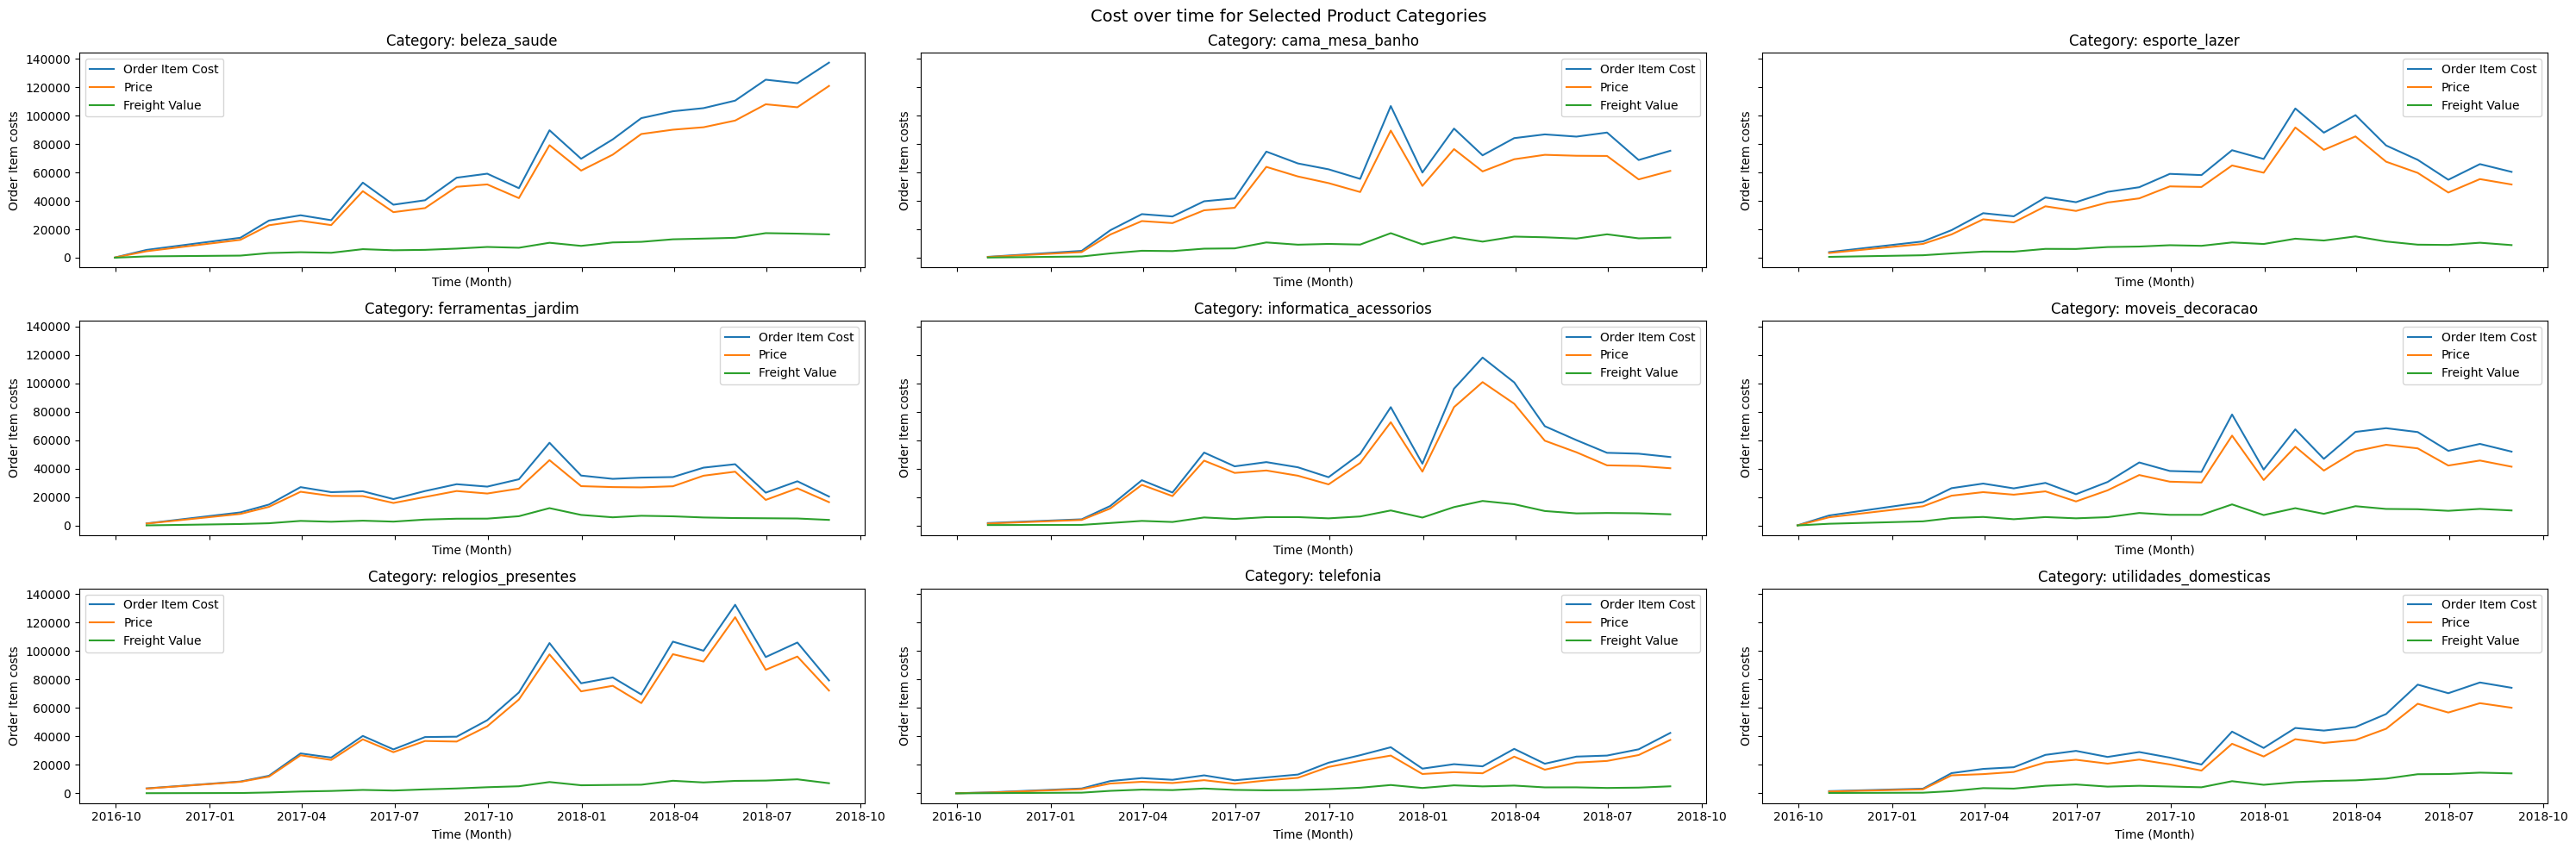

In [5]:
monthly_cost = (
    order_items_sample
    .groupby([
        "product_category_name",
        pd.Grouper(key="order_purchase_timestamp", freq="ME")
    ])
    .agg({"price": "sum", "freight_value": "sum"})
    .reset_index()
)
monthly_cost["order_cost"] = monthly_cost["price"] + monthly_cost["freight_value"]

fig, axes = plt.subplots(3, 3, figsize=(30, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, (product_category_name, df) in zip(axes, monthly_cost.groupby("product_category_name")):
    ax.plot(df["order_purchase_timestamp"], df["order_cost"], label="Order Item Cost")
    ax.plot(df["order_purchase_timestamp"], df["price"], label="Price")
    ax.plot(df["order_purchase_timestamp"], df["freight_value"], label="Freight Value")
    ax.set_title(f"Category: {product_category_name}")
    ax.set_xlabel("Time (Month)")
    ax.set_ylabel("Order Item costs")
    ax.legend()

plt.suptitle("Cost over time for Selected Product Categories", fontsize=14)
plt.tight_layout()
plt.savefig("../../docs/images/Cost over time for Selected Product Categories.png", dpi=300, bbox_inches="tight")
plt.show()

**Answer:** Total order item costs and total price for a product category by month show a behavior similar to the demand of product categories by month observed in the previous question, exhibiting a positive correlation. Freight value, over time, remains relatively stable and stays roughly constant.

### 5. How strong is the positive correlation between total cost and order item demand?

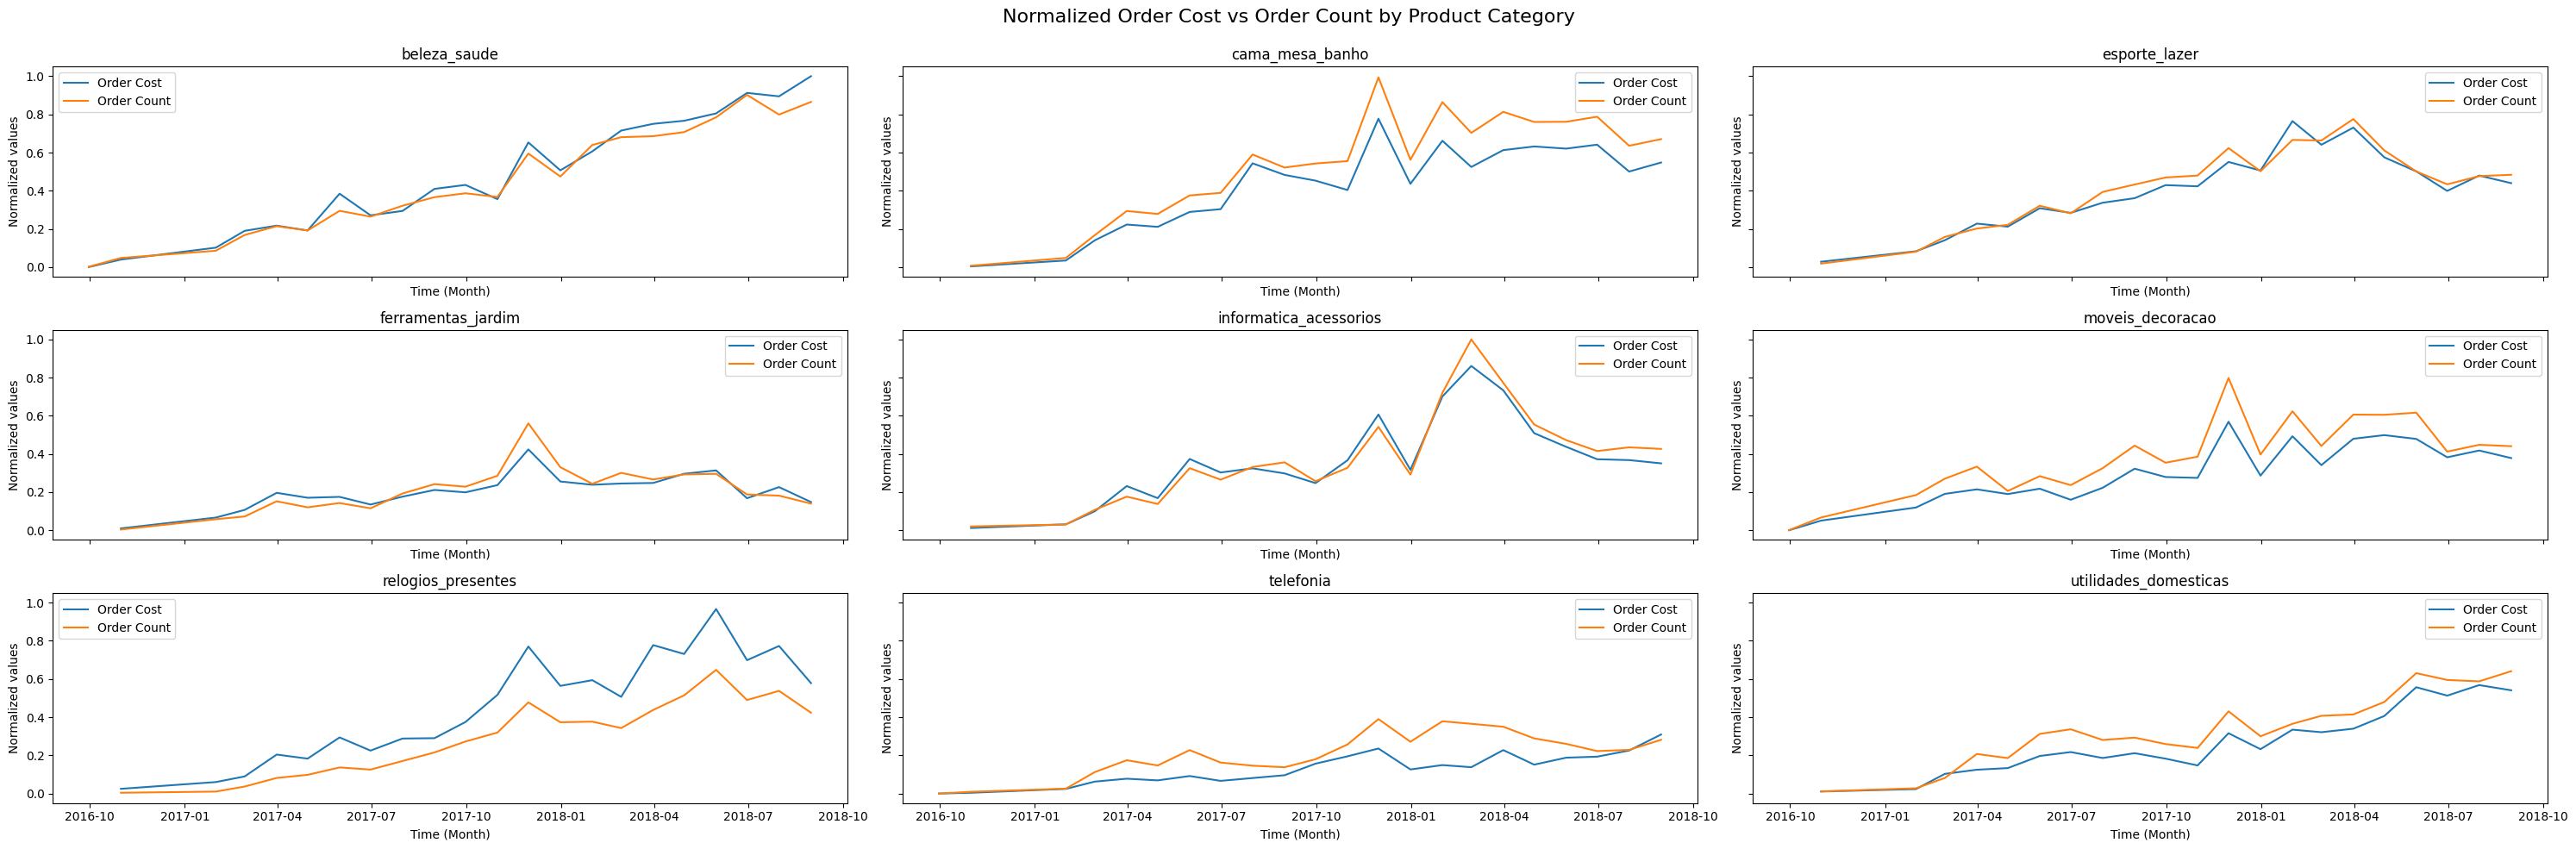

In [6]:
monthly_demand = (
    order_items_sample
    .groupby(["product_category_name", pd.Grouper(key="order_purchase_timestamp", freq="ME")])
    .size()
    .reset_index(name="order_count")
)

monthly_cost = (
    order_items_sample
    .groupby([
        "product_category_name",
        pd.Grouper(key="order_purchase_timestamp", freq="ME")
    ])
    .agg({"price": "sum", "freight_value": "sum"})
    .reset_index()
)
monthly_cost["order_cost"] = monthly_cost["price"] + monthly_cost["freight_value"]

monthly = monthly_cost.merge(monthly_demand, on=["product_category_name", "order_purchase_timestamp"])

scaler = MinMaxScaler()
monthly["order_cost_norm"] = scaler.fit_transform(monthly[["order_cost"]])
monthly["order_count_norm"] = scaler.fit_transform(monthly[["order_count"]])

fig, axes = plt.subplots(3, 3, figsize=(30, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, (category, df) in zip(axes, monthly.groupby("product_category_name")):
    ax.plot(df["order_purchase_timestamp"], df["order_cost_norm"], label="Order Cost")
    ax.plot(df["order_purchase_timestamp"], df["order_count_norm"], label="Order Count")
    ax.set_title(category)
    ax.set_xlabel("Time (Month)")
    ax.set_ylabel("Normalized values")
    ax.legend()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.suptitle("Normalized Order Cost vs Order Count by Product Category", fontsize=16)
plt.savefig("../../docs/images/Normalized Order Cost vs Order Count by Product Category.png", dpi=300, bbox_inches="tight")
plt.show()

**Answer:** There is a strong positive correlation between total order item cost and the number of order items per month.

## Takeaways

1. Demand forecasting at the **product level** is not feasible due to the low number of order items (≤ 3,000).
2. Demand forecasting at the **product category level** is possible for 14 categories that have ≥ 3,000 order items.
3. Demand at the product category level is **stable** and shows **seasonal patterns**, especially around end-of-year celebrations.
4. Total order item costs and total price have a **positive correlation** with the monthly demand of product categories.
5. This positive correlation is **strong**, resulting in **lower variations** across months.